<div style="background-color: #e8f4f8; border-left: 6px solid #3498db; padding: 20px; margin: 15px 0; border-radius: 4px;"><h2 style="margin-top: 0; color: #2c3e50; font-size: 22px;">Local Outlier Factor (LOF)</h2><div style="font-size: 16px; line-height: 1.6; color: #2c3e50;"><p>One of three unsupervised models we tested. On this dataset it produces <b>F1 = 0.35</b> - LOF specializes in isolated outliers, so it struggles with the sustained anomalies that dominate our data.</p><p><b>How it works:</b> LOF looks at the 50 closest neighbors of each point and measures how dense that local region is. It then compares this against the density of the neighbors themselves. Points that sit in sparse regions while their neighbors are in denser areas get flagged as anomalies.</p><p>The score reflects how isolated a point is relative to its surroundings, not just its absolute value - which makes LOF good at detecting <i>contextual point outliers</i>, but less suited for prolonged or gradual events.</p></div></div>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import LocalOutlierFactor
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

## Load data and split

In [2]:
data = pd.read_csv('../data/labeled.csv', parse_dates=['timestamp'])
split_point = int(len(data) * 0.8)
train_data = data.iloc[:split_point]
test_data = data.iloc[split_point:]

feature_columns = ['memory_pct', 'roll_mean_1h', 'roll_std_1h', 'roll_mean_24h',
                   'diff_1', 'diff_6', 'hour', 'minute', 'time_of_day', 'day_of_week', 'is_weekend']

X_train = train_data[feature_columns].values
X_test = test_data[feature_columns].values
y_test = test_data['label'].values

print('Anomalies in test:', y_test.sum())

Anomalies in test: 98


## Train LOF

**Hyperparameters:**
- `n_neighbors=50` — number of neighbors to compare density against
- `contamination=0.005` — expected fraction of anomalies in the data
- `novelty=True` — needed to predict on new (test) data

These values were chosen via grid search.

In [3]:
lof_model = LocalOutlierFactor(n_neighbors=50, contamination=0.005, novelty=True)
lof_model.fit(X_train)

lof_predictions = (lof_model.predict(X_test) == -1).astype(int)
lof_scores = -lof_model.score_samples(X_test)

print('Points flagged as anomaly:', lof_predictions.sum())

Points flagged as anomaly: 52


## Visualizing detections

- 🟢 **Green** — True Positive (correctly detected anomaly)
- 🔴 **Red X** — False Negative (real anomaly we missed)
- 🟠 **Orange triangle** — False Positive (false alarm)

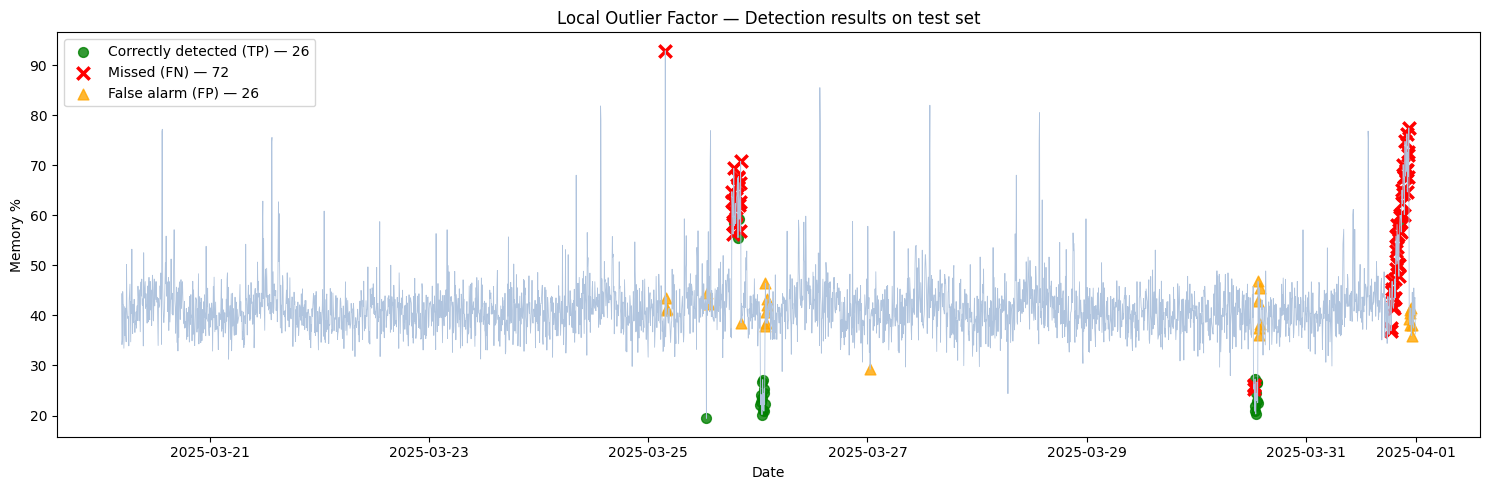

In [4]:
timestamps = test_data['timestamp'].values
memory = test_data['memory_pct'].values

true_positive_mask = (lof_predictions == 1) & (y_test == 1)
false_negative_mask = (lof_predictions == 0) & (y_test == 1)
false_positive_mask = (lof_predictions == 1) & (y_test == 0)

plt.figure(figsize=(15, 5))
plt.plot(timestamps, memory, color='lightsteelblue', linewidth=0.6)
plt.scatter(timestamps[true_positive_mask], memory[true_positive_mask],
            color='green', s=50, alpha=0.8, label=f'Correctly detected (TP) — {true_positive_mask.sum()}')
plt.scatter(timestamps[false_negative_mask], memory[false_negative_mask],
            color='red', marker='x', s=80, linewidths=2.5, label=f'Missed (FN) — {false_negative_mask.sum()}')
plt.scatter(timestamps[false_positive_mask], memory[false_positive_mask],
            color='orange', marker='^', s=60, alpha=0.8, label=f'False alarm (FP) — {false_positive_mask.sum()}')
plt.xlabel('Date')
plt.ylabel('Memory %')
plt.title('Local Outlier Factor — Detection results on test set')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

## Confusion matrix

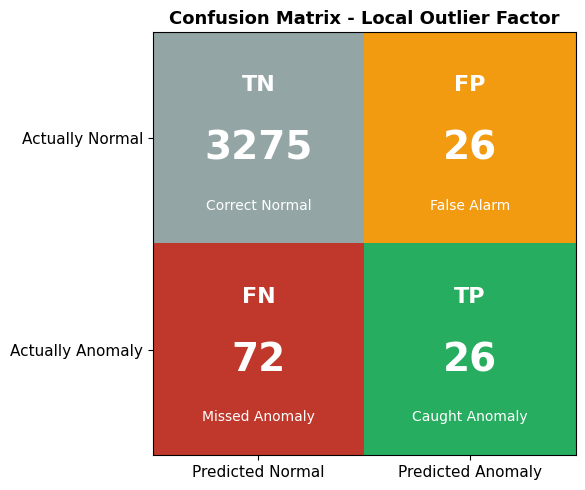

In [5]:
def pretty_cm(cm, title='Confusion Matrix'):
    fig, ax = plt.subplots(figsize=(7, 5))
    # 4 distinct colors - one per outcome category
    rgb = np.zeros((2, 2, 3))
    rgb[0, 0] = [0.58, 0.65, 0.65]  # TN: gray (correct but routine)
    rgb[0, 1] = [0.95, 0.61, 0.07]  # FP: orange (false alarm)
    rgb[1, 0] = [0.75, 0.22, 0.17]  # FN: dark red (MISSED, worst)
    rgb[1, 1] = [0.15, 0.68, 0.38]  # TP: bright green (caught it, best)
    ax.imshow(rgb)
    labels = [['TN', 'FP'], ['FN', 'TP']]
    descriptions = [['Correct Normal', 'False Alarm'], ['Missed Anomaly', 'Caught Anomaly']]
    for i in range(2):
        for j in range(2):
            ax.text(j, i - 0.25, labels[i][j], ha='center', va='center',
                    fontsize=16, fontweight='bold', color='white')
            ax.text(j, i + 0.05, str(cm[i, j]), ha='center', va='center',
                    fontsize=28, fontweight='bold', color='white')
            ax.text(j, i + 0.32, descriptions[i][j], ha='center', va='center',
                    fontsize=10, color='white')
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(['Predicted Normal', 'Predicted Anomaly'], fontsize=11)
    ax.set_yticklabels(['Actually Normal', 'Actually Anomaly'], fontsize=11)
    ax.set_title(title, fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

cm = confusion_matrix(y_test, lof_predictions)
pretty_cm(cm, title='Confusion Matrix - Local Outlier Factor')

## Evaluation

- **Precision** — alerts that are real anomalies
- **Recall** — anomalies caught
- **F1** — balanced score
- **ROC-AUC** — how well the model ranks anomalies vs normals

In [6]:
print(classification_report(y_test, lof_predictions, target_names=['Normal','Anomaly'], zero_division=0))
print('ROC-AUC:', round(roc_auc_score(y_test, lof_scores), 4))

              precision    recall  f1-score   support

      Normal       0.98      0.99      0.99      3301
     Anomaly       0.50      0.27      0.35        98

    accuracy                           0.97      3399
   macro avg       0.74      0.63      0.67      3399
weighted avg       0.96      0.97      0.97      3399

ROC-AUC: 0.9027


<div style="background-color: #fdf6e3; border-left: 6px solid #f39c12; padding: 20px; margin: 15px 0; border-radius: 4px;"><h3 style="margin-top: 0; color: #b9770e; font-size: 20px;">Interpretation</h3><div style="font-size: 16px; line-height: 1.6; color: #5d4e1d;"><p>LOF achieves <b>F1 = 0.35</b> on this dataset - moderate performance.</p><p>It works well for:</p><ul><li>Sudden spikes and drops (clear density outliers)</li><li>Points that stand out from their immediate context</li></ul><p>It struggles with:</p><ul><li>Sustained anomalies where each individual point still looks normal compared to its neighbors</li><li>Gradual ramps - the very pattern type that dominates our injected anomalies</li></ul><p>Since our dataset has many sustained anomalies, LOF on its own is not the right tool. But it captures something the other models do not, which is why we include it in the cascading ensemble.</p></div></div>

<div style="background-color: #e8f8e8; border-left: 6px solid #27ae60; padding: 20px; margin: 15px 0; border-radius: 4px;"><h3 style="margin-top: 0; color: #1e8449; font-size: 20px;">Summary - Model Performance</h3><div style="font-size: 16px; line-height: 1.6; color: #1e8449;"><p><b>Local Outlier Factor:</b></p><ul><li><b>F1 ~ 0.35</b> on this dataset</li><li><b>Recall ~ 27%</b> - misses many of the sustained anomalies</li><li><b>Precision ~ 50%</b> - about half of its alerts are real</li><li><b>ROC-AUC ~ 0.90</b> - still ranks anomalies above normals fairly well</li></ul><p><b>Strengths:</b> Strong density-based detection for isolated outliers. Captures a different signal than tree-based methods.</p><p><b>Weaknesses:</b> The fundamental design of LOF assumes anomalies are point-like. Sustained patterns (memory leaks, gradual shifts) blend in with their neighbors and slip past it.</p><p><b>Takeaway:</b> LOF is not the best standalone choice for this kind of data, but its complementary perspective makes it valuable as part of the cascading ensemble (see <code>best_unsupervised.ipynb</code>).</p></div></div>